In [2]:
import timeit as t
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
#### %matplotlib notebook
%matplotlib inline

# Setup styles for plotting
style_list = ['default', 'classic'] + sorted(
        style for style in plt.style.available if style != 'classic')
plt.style.use(style_list[10])
print(style_list)

['default', 'classic', 'Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [3]:
# 2.1 Function to find Nth Fibonacci term
def FibonacciRec(N:int):
    # Base Case
    if (N < 2):
        return N

    # Recursively computing the term
    # using recurrence relation
    return FibonacciRec(N - 1) + FibonacciRec(N - 2)

# Test fibonacci: compute results for N 1 .. 20



### 2.2 Execution time

Example:
`t.timeit('quicksort(data)','from __main__ import data,quicksort', number = num)`


In [4]:
# Measure execution time : 
fibNumber = 10

t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)

print('Fibonnaci for ', fibNumber, ' execution time sec: ', t_fib)

Fibonnaci for  10  execution time sec:  8.400005754083395e-06


[7.00005330e-07 7.99947884e-07 1.00000761e-06 7.59999966e-06
 7.18999654e-05 7.74200016e-04 8.31710000e-03 9.16221000e-02]


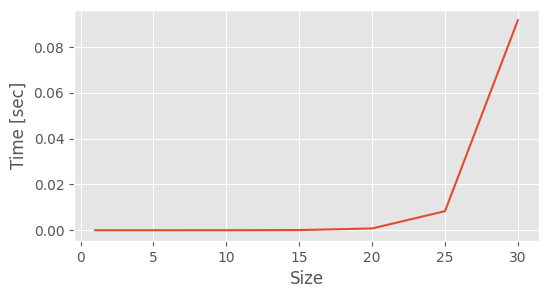

In [5]:
# 2.3 Plot graph of Fibonnaci execution time

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30]
#
for n in n_list:
    fibNumber = n
    t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)
    t_list = np.append(t_list, t_fib)
print(t_list)


ax = plt.figure(figsize=[6,3])
plt.plot(n_list,t_list)
plt.xlabel('Size')
plt.ylabel('Time [sec]')
plt.show()


In [6]:
# 2.4 Class for algorithm testing
from utils import Algorithm

# Testing
a = Algorithm()
a.run()


Algorithm.run_once, operations:  10
 >>  0 , msec: 0.135 , operations:  10
 >>>  Algorithm  > Total run() sec:  0.00015489995712414384  Avg iter msec: 0.15489995712414384


{'name': 'Algorithm',
 'avg_msec': 0.15489995712414384,
 'avg_O': 10.0,
 'niter': 1,
 'output': []}

In [7]:
# 2.5  Fibonnaci algoritem z uporabo Alogrithm

class FibonacciRecursion(Algorithm):
    def __init__(self):
        self.name = "FibonacciRecursion"

    # Function to find Nth Fibonacci term
    def FibonacciR(self, N:int):
        # Count each call of the function
        self.count_op += 1

        # Base Case
        if (N < 2):
            return N

        # Recursively computing the term
        # using recurrence relation
        return self.FibonacciR(N - 1) + self.FibonacciR(N - 2)

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.FibonacciR(N)

        return self.result_data


s = FibonacciRecursion()
s.data_params = {'N': 10}
print('Test result: ', s.run(10))


 >>  0 , msec: 0.019 , operations:  177
 >>  1 , msec: 0.021 , operations:  177
 >>  2 , msec: 0.017 , operations:  177
 >>  3 , msec: 0.017 , operations:  177
 >>  4 , msec: 0.017 , operations:  177
 >>  5 , msec: 0.017 , operations:  177
 >>  6 , msec: 0.029 , operations:  177
 >>  7 , msec: 0.018 , operations:  177
 >>  8 , msec: 0.018 , operations:  177
 >>  9 , msec: 0.017 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  0.0006290000164881349  Avg iter msec: 0.06290000164881349
Test result:  {'name': 'FibonacciRecursion', 'avg_msec': 0.06290000164881349, 'avg_O': 177.0, 'niter': 10, 'output': 55}


 >>  0 , msec: 0.002 , operations:  1
 >>>  FibonacciRecursion  > Total run() sec:  5.360000068321824e-05  Avg iter msec: 0.05360000068321824
 >>  0 , msec: 0.001 , operations:  5
 >>>  FibonacciRecursion  > Total run() sec:  1.5900004655122757e-05  Avg iter msec: 0.015900004655122757
 >>  0 , msec: 0.002 , operations:  15
 >>>  FibonacciRecursion  > Total run() sec:  1.5600002370774746e-05  Avg iter msec: 0.015600002370774746
 >>  0 , msec: 0.017 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  2.929999027401209e-05  Avg iter msec: 0.02929999027401209
 >>  0 , msec: 0.199 , operations:  1973
 >>>  FibonacciRecursion  > Total run() sec:  0.00021169998217374086  Avg iter msec: 0.21169998217374086
 >>  0 , msec: 2.146 , operations:  21891
 >>>  FibonacciRecursion  > Total run() sec:  0.002162200049497187  Avg iter msec: 2.162200049497187
 >>  0 , msec: 24.264 , operations:  242785
 >>>  FibonacciRecursion  > Total run() sec:  0.024306099978275597  Avg iter msec: 24.306099

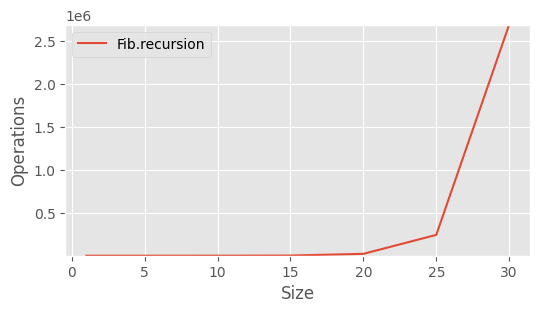

In [29]:
# 2.6 Testing Fibonacci recursion

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30]

s = FibonacciRecursion()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])


ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list, label='Fib.recursion')

O2n = [2**n for n in n_list]
On2 = [n*n for n in n_list]
#plt.plot(size, O2n, 'b--', label='O(2^n)')
#plt.plot(size, On2, 'g--', label='O(n^2)')

plt.ylim([1, max(oper_list)])
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
#plt.yscale('log')

plt.show()

In [9]:
# 2.7 Fibonnaci algorithm optimized

class FibonacciOptimized(Algorithm):
    def __init__(self):
        self.name = "FibonacciOptimized"

    # Function to find Nth Fibonacci term
    def Fibonacci(self, N):
        f=[0]*(N + 2)
        # 0th and 1st number of the
        # series are 0 and 1
        f[0] = 0
        f[1] = 1
        # Iterate over the range [2, N]
        for i in range(2,N+1) :
            self.count_op += 1
            # Add the previous 2 numbers
            # in the series and store it
            f[i] = f[i - 1] + f[i - 2]
        # Return Nth Fibonacci Number
        return f[N]

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.Fibonacci(N)

        return self.result_data


s = FibonacciOptimized()
s.data_params = {'N': 10}
print(s.run(1))



 >>  0 , msec: 0.004 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  0.00011860002996399999  Avg iter msec: 0.11860002996399999
{'name': 'FibonacciOptimized', 'avg_msec': 0.11860002996399999, 'avg_O': 9.0, 'niter': 1, 'output': 55}


In [10]:
# 2.7 Testing Fibonacci optimized



### Sorting algorithms

The task that we will be solving in this exercise will be a simple sorting of numbers in ascending order. Again when dealing with such a task, we must consider several scenarios (at least if we want to be objective in our measurements):
* **Optimal** - in this case the numbers are sorted allready, which means that the algorithm must only detect this as quick as possible.
* **Worst** - in this case the numbers are sorted but in a reverse order.
* **Normal** - the numbers are sorted randomly


In [11]:
def insertionSort2(array):
    d = array.copy()
    for j in range(1, len(d)):
        key = d[j]
        i = j - 1
        while i >= 0 and d[i] > key:
            d[i + 1] = d[i]
            i = i - 1
        d[i + 1] = key
    return d

In [12]:
# Create data set
def createSet(type = None, size = 100):
    if type == 1:  #return numbers sorted in ascening order -> best case
        return np.linspace(1,size,size).tolist() 
    elif type == 2: #return numbers in descending order -> wost case
        return np.linspace(size,1,size).tolist()
    else: #return a random assortment of numbers
        return (np.trunc(np.absolute(size*10/2.0 + size*10/5.0*np.random.randn(size)))/10).tolist()

In [30]:
# 3.1 Try type parameters : 1..3, print data
print("type=1 : ", createSet(1,20))


type=1 :  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]


In [31]:
# 3.3 Test insertionSort2
data = createSet(3, size=100)
result = insertionSort2(data)
print(data)
print(result)


[69.1, 1.1, 37.6, 73.6, 35.4, 54.6, 33.5, 52.8, 56.6, 81.4, 47.6, 67.8, 45.5, 31.1, 51.1, 33.5, 43.3, 60.0, 94.4, 6.2, 48.6, 21.5, 34.8, 52.6, 66.1, 81.0, 40.5, 33.0, 63.7, 72.3, 43.9, 0.5, 40.2, 58.8, 33.6, 34.5, 56.5, 72.7, 46.8, 44.8, 63.5, 54.8, 30.5, 77.8, 46.5, 35.1, 59.8, 55.2, 37.7, 60.5, 75.4, 45.7, 89.1, 57.3, 89.8, 29.8, 57.4, 57.2, 73.7, 56.3, 37.2, 44.6, 31.5, 27.6, 42.3, 38.1, 50.3, 38.3, 45.0, 112.3, 39.6, 57.3, 40.4, 31.4, 56.2, 26.3, 69.0, 44.1, 13.1, 55.6, 47.5, 33.1, 56.8, 115.6, 89.2, 78.1, 54.8, 79.7, 15.5, 14.3, 71.1, 58.8, 57.9, 51.5, 25.2, 30.6, 80.2, 72.9, 48.0, 52.7]
[0.5, 1.1, 6.2, 13.1, 14.3, 15.5, 21.5, 25.2, 26.3, 27.6, 29.8, 30.5, 30.6, 31.1, 31.4, 31.5, 33.0, 33.1, 33.5, 33.5, 33.6, 34.5, 34.8, 35.1, 35.4, 37.2, 37.6, 37.7, 38.1, 38.3, 39.6, 40.2, 40.4, 40.5, 42.3, 43.3, 43.9, 44.1, 44.6, 44.8, 45.0, 45.5, 45.7, 46.5, 46.8, 47.5, 47.6, 48.0, 48.6, 50.3, 51.1, 51.5, 52.6, 52.7, 52.8, 54.6, 54.8, 54.8, 55.2, 55.6, 56.2, 56.3, 56.5, 56.6, 56.8, 57.2, 57.3, 

In [32]:
# Measurement class for algorithm complexity, insertion sort

class InsertionSort(Algorithm):
    def __init__(self):
        self.name = "Insertion Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()

    def insertionSort(self, array):
        d = array.copy()
        for j in range(1, len(d)):
            key = d[j]
            i = j - 1
            while i >= 0 and d[i] > key:
                self.count_op+=1
                d[i + 1] = d[i]
                i = i - 1
            d[i + 1] = key
        return d


    def run_once(self):
        self.result_data = self.insertionSort(self.input_data)
        return self.result_data

In [36]:
# 3.4 Test InsertionSort class

s = InsertionSort()
s.data_params = {'size': 1000, 'type': 2}

test_results = s.run(2)


print('Unsorted data: ', s.input_data)
#print('Sorted data: ', s.result_data)

print('\n TEST RESULTS :  ', test_results)


 >>  0 , msec: 53.361 , operations:  499500
 >>  1 , msec: 53.086 , operations:  499500
 >>>  Insertion Sort  > Total run() sec:  0.10662450001109391  Avg iter msec: 53.31225000554696
Unsorted data:  [1000.0, 999.0, 998.0, 997.0, 996.0, 995.0, 994.0, 993.0, 992.0, 991.0, 990.0, 989.0, 988.0, 987.0, 986.0, 985.0, 984.0, 983.0, 982.0, 981.0, 980.0, 979.0, 978.0, 977.0, 976.0, 975.0, 974.0, 973.0, 972.0, 971.0, 970.0, 969.0, 968.0, 967.0, 966.0, 965.0, 964.0, 963.0, 962.0, 961.0, 960.0, 959.0, 958.0, 957.0, 956.0, 955.0, 954.0, 953.0, 952.0, 951.0, 950.0, 949.0, 948.0, 947.0, 946.0, 945.0, 944.0, 943.0, 942.0, 941.0, 940.0, 939.0, 938.0, 937.0, 936.0, 935.0, 934.0, 933.0, 932.0, 931.0, 930.0, 929.0, 928.0, 927.0, 926.0, 925.0, 924.0, 923.0, 922.0, 921.0, 920.0, 919.0, 918.0, 917.0, 916.0, 915.0, 914.0, 913.0, 912.0, 911.0, 910.0, 909.0, 908.0, 907.0, 906.0, 905.0, 904.0, 903.0, 902.0, 901.0, 900.0, 899.0, 898.0, 897.0, 896.0, 895.0, 894.0, 893.0, 892.0, 891.0, 890.0, 889.0, 888.0, 887.0, 

In [37]:
# 3.5 Complexity of Insertion sort

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000,3000]

s = InsertionSort()
s.data_params['type'] = 3

# Loop over all dataset sizes
for n in n_list:
    s.data_params['size'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

# Plot graph





 >>  0 , msec: 0.113 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  0.00026249996153637767  Avg iter msec: 0.26249996153637767
 >>  0 , msec: 0.027 , operations:  19
 >>>  Insertion Sort  > Total run() sec:  4.9099966417998075e-05  Avg iter msec: 0.049099966417998075
 >>  0 , msec: 0.026 , operations:  100
 >>>  Insertion Sort  > Total run() sec:  4.0700018871575594e-05  Avg iter msec: 0.040700018871575594
 >>  0 , msec: 0.088 , operations:  703
 >>>  Insertion Sort  > Total run() sec:  0.00010300002759322524  Avg iter msec: 0.10300002759322524
 >>  0 , msec: 0.269 , operations:  2437
 >>>  Insertion Sort  > Total run() sec:  0.00028330000350251794  Avg iter msec: 0.28330000350251794
 >>  0 , msec: 0.917 , operations:  9711
 >>>  Insertion Sort  > Total run() sec:  0.0009318999946117401  Avg iter msec: 0.9318999946117401
 >>  0 , msec: 6.195 , operations:  60508
 >>>  Insertion Sort  > Total run() sec:  0.006221799994818866  Avg iter msec: 6.221799994818866
 >>  0 , msec: 3

In [19]:
def quicksort(arr):
    """ Quicksort a list

    :type arr: list
    :param arr: List to sort
    :returns: list -- Sorted list
    """
    if len(arr) <= 1:
        return arr
    else:
        return quicksort([x for x in arr[1:] if x<arr[0]]) + [arr[0]] + quicksort([x for x in arr[1:] if x>=arr[0]])

In [20]:
class QuickSort(Algorithm):
    def __init__(self):
        self.name = "Quick Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()


    # Function to find the partition position
    def partition(self, array, low, high):
    
        # Choose the rightmost element as pivot
        pivot = array[high]
    
        # Pointer for greater element
        i = low - 1
    
        # Traverse through all elements
        # compare each element with pivot
        for j in range(low, high):
            if array[j] <= pivot:
    
                # If element smaller than pivot is found
                # swap it with the greater element pointed by i
                i = i + 1
    
                # Swapping element at i with element at j
                (array[i], array[j]) = (array[j], array[i])
                self.count_op+=1
    
        # Swap the pivot element with
        # the greater element specified by i
        (array[i + 1], array[high]) = (array[high], array[i + 1])
        self.count_op+=1
    
        # Return the position from where partition is done
        return i + 1
 
 
    # Function to perform quicksort
    def quicksort(self, array, low, high):
        if low < high:
    
            # Find pivot element such that
            # element smaller than pivot are on the left
            # element greater than pivot are on the right
            pi = self.partition(array, low, high)
    
            # Recursive call on the left of pivot
            self.quicksort(array, low, pi - 1)
    
            # Recursive call on the right of pivot
            self.quicksort(array, pi + 1, high)


    def run_once(self):
        N = len(self.input_data)
        self.result_data = self.quicksort(self.input_data, 0, N-1)
        return self.result_data

In [21]:
# 3.6 Code testing Quick sort



